# 📊 Customer Purchase Behaviour & Profitability Analysis

## 🎯 Business Objective
This project analyzes customer purchasing patterns, revenue performance,
and profitability metrics to identify key business drivers and improvement areas.

In [4]:
# Establishing connection to MySQL database.
# This connection allows us to extract business sales data, stored in the 'business' database for analysis.
import pymysql

connection = pymysql.connect(
    host='localhost',
    user='root',
    password='Somesh@52',
    database='business'
)

print("Connected successfully")

Connected successfully


In [1]:
# Importing data from SQL database into pandas DataFrame
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import pandas as pd

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="Somesh@52",   
    host="localhost",
    database="business"
)

engine = create_engine(url)

df = pd.read_sql("SELECT * FROM sales_data", engine)
df.head()

,order_id,customer_id,order_date,region,product_category,quality,sales,cost,profit,profit_margin,order_date_clean
0,ORD00001,CUST0328,25-04-2023,North,Clothing,2,1271.41,929.92,341.49,26.86,2023-04-25
1,ORD00002,CUST0347,31-03-2023,West,Electronics,1,649.74,327.92,321.82,49.53,2023-03-31
2,ORD00003,CUST0309,28-01-2023,South,Home Appliances,4,1258.11,836.86,421.25,33.48,2023-01-28
3,ORD00004,CUST0004,13-06-2023,West,Clothing,3,946.30,786.13,160.17,16.93,2023-06-13
4,ORD00005,CUST0173,15-04-2023,North,Office Supplies,1,1923.10,1066.90,856.20,44.52,2023-04-15


In [4]:
# Inspecting dataset structure
# Checking column names, data types, and missing values to understand data quality before analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1500 non-null   object 
 1   customer_id       1500 non-null   object 
 2   order_date        1500 non-null   object 
 3   region            1500 non-null   object 
 4   product_category  1500 non-null   object 
 5   quality           1500 non-null   int64  
 6   sales             1500 non-null   float64
 7   cost              1500 non-null   float64
 8   profit            1500 non-null   float64
 9   profit_margin     1500 non-null   float64
 10  order_date_clean  1500 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 129.0+ KB


In [9]:
# Generating summary statistics for numerical columns to understand central tendency, spread, and distribution
df.describe()

,quality,sales,cost,profit,profit_margin
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2.992000,2593.112467,1628.424640,964.687827,37.045500
std,1.428273,1360.021562,924.593797,641.236049,12.976326
min,1.000000,210.010000,89.170000,32.650000,15.030000
25%,2.000000,1412.530000,853.770000,451.217500,25.747500
50%,3.000000,2569.500000,1579.735000,824.335000,36.700000
75%,4.000000,3744.957500,2267.752500,1354.555000,47.867500
max,5.000000,4999.780000,4098.220000,2883.870000,59.990000


In [10]:
# Checking missing values
df.isnull().sum()

order_id            0
customer_id         0
order_date          0
region              0
product_category    0
quality             0
sales               0
cost                0
profit              0
profit_margin       0
order_date_clean    0
dtype: int64

In [7]:
# Checking duplicate values
df.duplicated().sum()

0

# 1. Total Revenue

In [15]:
total_revenue = df['sales'].sum()
total_revenue

3889668.6999999997

* The business generated ₹3.89M in total revenue

# 2. Total Profit

In [16]:
total_profit = df['profit'].sum()
total_profit

1447031.7400000002

* The business generated ₹1.4M profit

# 3. Total Orders

In [18]:
total_orders = df['order_id'].nunique()
total_orders

1500

* company got 1500 orders 

# 4. Average Order Value (AOV)

In [38]:
aov = df['sales'].sum() / df['order_id'].nunique()
aov

2593.1124666666665

* The company generates approximately ₹2.6K revenue per order, indicating healthy transaction value per customer.

# 5. Customer Retention Analysis

In [28]:
customer_counts = df['customer_id'].value_counts()

repeat_customers = customer_counts[customer_counts > 1].count()
total_customers = df['customer_id'].nunique()

retention_rate = (repeat_customers / total_customers) * 100
retention_rate

90.72164948453609

* 90.7% of repeat customers.

# 6. Monthly Revenue Trend

In [11]:
# Converting order_date column to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')
df['month'] = df['order_date'].dt.month

In [11]:
monthly_revenue = df.groupby('month')['sales'].sum().sort_values(ascending=False)
monthly_revenue

month
5     501597.02
4     445464.62
1     434183.82
3     411860.20
2     401233.34
6     354731.04
11    245600.55
8     233930.02
7     233000.74
10    231382.71
9     206925.13
12    189759.51
Name: sales, dtype: float64

In [12]:
# Creating month column for time-based analysis
df['month'] = df['order_date'].dt.month

In [16]:
df.head(5)

,order_id,customer_id,order_date,region,product_category,quality,sales,cost,profit,profit_margin,order_date_clean,month
0,ORD00001,CUST0328,2023-04-25,North,Clothing,2,1271.41,929.92,341.49,26.86,2023-04-25,4
1,ORD00002,CUST0347,2023-03-31,West,Electronics,1,649.74,327.92,321.82,49.53,2023-03-31,3
2,ORD00003,CUST0309,2023-01-28,South,Home Appliances,4,1258.11,836.86,421.25,33.48,2023-01-28,1
3,ORD00004,CUST0004,2023-06-13,West,Clothing,3,946.30,786.13,160.17,16.93,2023-06-13,6
4,ORD00005,CUST0173,2023-04-15,North,Office Supplies,1,1923.10,1066.90,856.20,44.52,2023-04-15,4


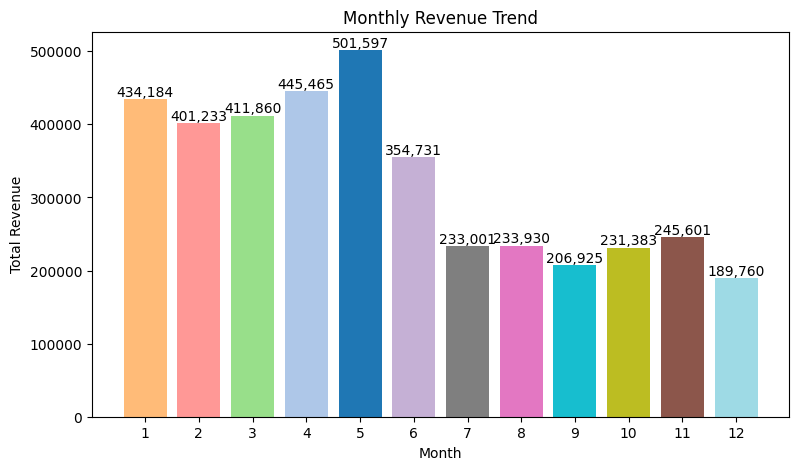

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,5))

# Generate different colors automatically
colors = plt.cm.tab20(np.linspace(0, 1, len(monthly_revenue)))

bars = plt.bar(monthly_revenue.index,
               monthly_revenue.values,
               color=colors)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

# 🔹 Force x-axis to show 1 to 12
plt.xticks(range(1,13))

# 🔹 Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:,.0f}',
             ha='center',
             va='bottom')

plt.show()

# Insight:

* Identified highest revenue month that is "MAY".

* Identified lowest revenue month that is "DECEMBER"

# 7. Region-wise Revenue

In [29]:
region_sales = df.groupby('region')['sales'].sum()
region_sales

region
East      933836.44
North    1030674.02
South     962833.79
West      962324.45
Name: sales, dtype: float64

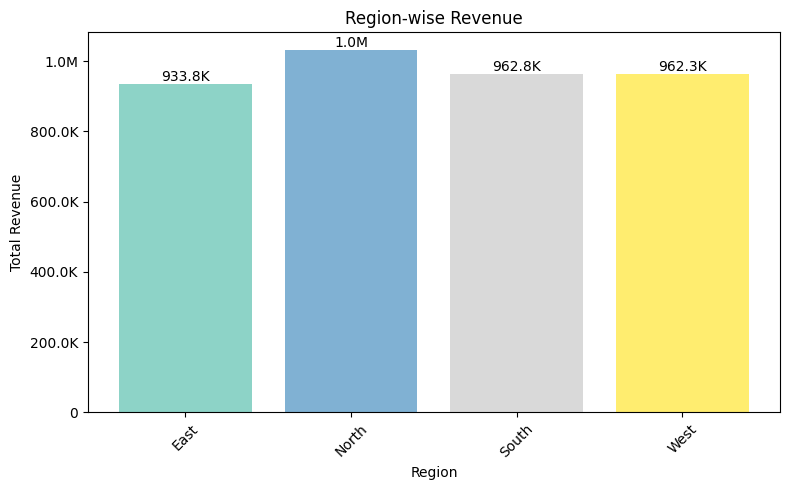

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))

# Different colors
colors = plt.cm.Set3(np.linspace(0, 1, len(region_sales)))

bars = plt.bar(region_sales.index,
               region_sales.values,
               color=colors)

plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

# 🔹 Format Y-axis as K / M
def format_number(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.1f}K'
    return f'{x:.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_number))

# 🔹 Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             format_number(height, None),
             ha='center',
             va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Approx % Contribution

* North ≈ 25.9%

* South ≈ 24.9%

* West ≈ 24.9%

* East ≈ 24.2%

Revenue distribution is quite balanced.

# 8. Product Category Contribution

In [33]:
category_sales = df.groupby('product_category')['sales'].sum()
category_sales

product_category
Clothing           764526.09
Electronics        812772.57
Furniture          744397.04
Home Appliances    736456.56
Office Supplies    831516.44
Name: sales, dtype: float64

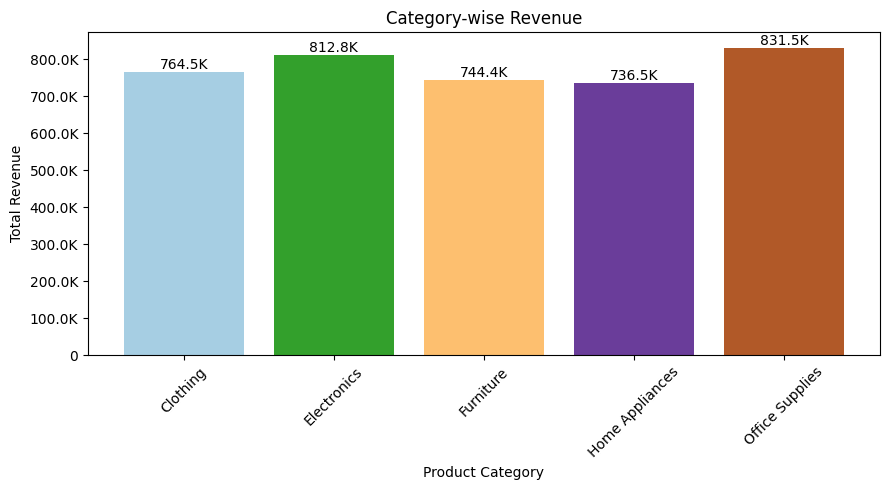

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(9,5))

# Generate different colors
colors = plt.cm.Paired(np.linspace(0, 1, len(category_sales)))

bars = plt.bar(category_sales.index,
               category_sales.values,
               color=colors)

plt.title("Category-wise Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

# 🔹 Format Y-axis as K / M
def format_number(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.1f}K'
    return f'{x:.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_number))

# 🔹 Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             format_number(height, None),
             ha='center',
             va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
* Office Supplies → 831.5K (Highest)

* Electronics → 812.8K

* Clothing → 764.5K

* Furniture → 744.4K

* Home Appliances → 736.5K (Lowest)

Revenue is evenly distributed across categories, with Office Supplies and Electronics slightly outperforming others.

# 9. Profit Analysis

In [36]:
category_profit = df.groupby('product_category')['profit'].sum()
category_profit

product_category
Clothing           278904.24
Electronics        294028.31
Furniture          273487.53
Home Appliances    284328.90
Office Supplies    316282.76
Name: profit, dtype: float64

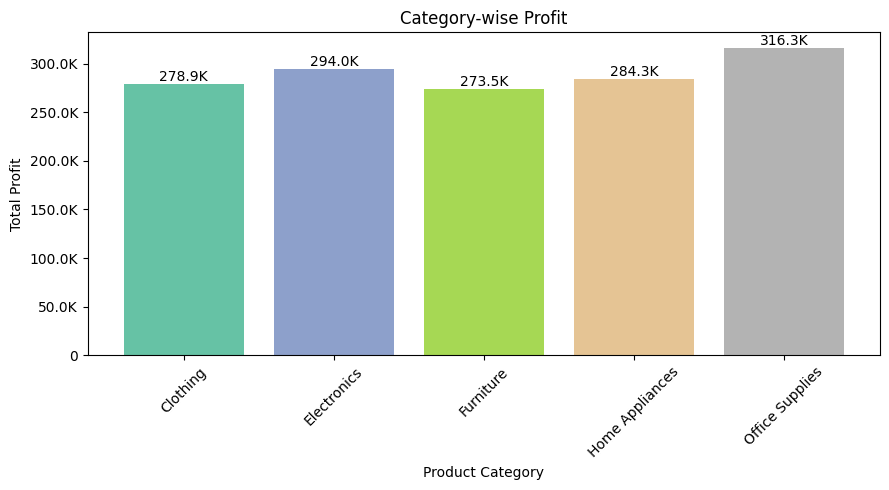

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(9,5))

# Generate different colors
colors = plt.cm.Set2(np.linspace(0, 1, len(category_profit)))

bars = plt.bar(category_profit.index,
               category_profit.values,
               color=colors)

plt.title("Category-wise Profit")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

# 🔹 Format Y-axis as K / M
def format_number(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.1f}K'
    return f'{x:.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_number))

# 🔹 Add profit values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             format_number(height, None),
             ha='center',
             va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
Profit is fairly evenly distributed across categories, with Office Supplies emerging as the most profitable segment.

# 10. Profit Margin Distribution

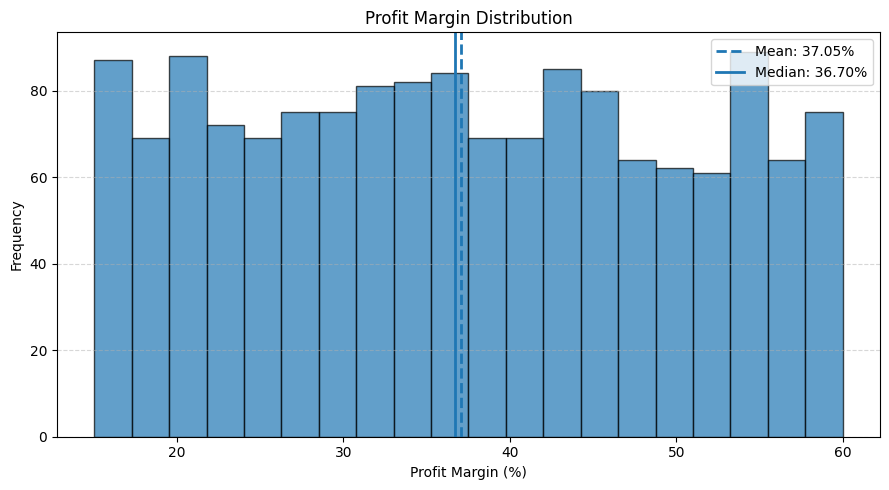

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,5))

# Histogram
counts, bins, patches = plt.hist(df['profit_margin'],
                                 bins=20,
                                 edgecolor='black',
                                 alpha=0.7)

# Mean & Median
mean_pm = df['profit_margin'].mean()
median_pm = df['profit_margin'].median()

plt.axvline(mean_pm, linestyle='--', linewidth=2, label=f"Mean: {mean_pm:.2f}%")
plt.axvline(median_pm, linestyle='-', linewidth=2, label=f"Median: {median_pm:.2f}%")

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Profit Margin Insights

- **Mean Profit Margin:** 37.05%  
- **Median Profit Margin:** 36.70%  
- **Profit Margin Range:** 15% – 60%  

**Interpretation:**  
The profit margin distribution is stable and centered around **37%**, indicating consistent pricing efficiency and strong cost management. The close alignment between mean and median suggests minimal skewness and limited impact of outliers.

# 11. Correlation Analysis

In [20]:
df[['sales','profit','profit_margin']].corr()

,sales,profit,profit_margin
sales,1.000000,0.806087,0.022992
profit,0.806087,1.000000,0.540190
profit_margin,0.022992,0.540190,1.000000


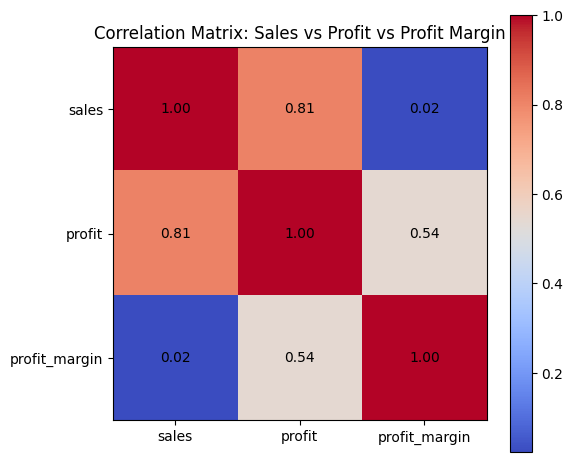

In [25]:
# Visualizing correlation between Sales, Profit, and Profit Margin using heatmap.

import matplotlib.pyplot as plt
import numpy as np

corr_matrix = df[['sales','profit','profit_margin']].corr()

plt.figure(figsize=(6,5))

# Create heatmap
plt.imshow(corr_matrix, cmap='coolwarm')

# Add color bar
plt.colorbar()

# Add axis labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add correlation values inside boxes
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i,
                 f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center',
                 va='center')

plt.title("Correlation Matrix: Sales vs Profit vs Profit Margin")
plt.tight_layout()
plt.show()

* Sales and profit show strong positive correlation (0.81), indicating revenue growth directly drives profitability. However, profit margin shows negligible correlation with sales, suggesting margin improvement strategies can independently enhance profit performance.

# 12. Top Customers Analysis

In [23]:
top_customers = df.groupby('customer_id')['sales'].sum().sort_values(ascending=False).head(5)
top_customers

customer_id
CUST0136    35051.09
CUST0028    31067.05
CUST0055    27891.96
CUST0158    26478.04
CUST0154    24678.51
Name: sales, dtype: float64

* The top 5 customers contribute only 3.73% of total revenue, indicating low revenue concentration and reduced dependency risk on individual customers.

# 📊 Sales & Profitability Analysis Report


---

## 📈 Key Business Insights

- 📅 **May** recorded the highest revenue.
- 🌍 **North** region generated maximum revenue.
- 🏆 **Office Supplies** product category drives majority of business revenue.
- 🔁 **Customer Retention Rate:** 90.7%.
- 💰 **Average Order Value (AOV):** ₹2.6K.
- 📊 **Overall Average Profit Margin:** 37%.

---

## 💡 Business Recommendations

- 🎯 Focus marketing campaigns during high-performing months.
- 📍 Improve operations in underperforming regions.
- 🛍 Promote high-margin product categories.
- 🤝 Implement loyalty programs to increase customer retention.

---

## 📌 Project Conclusion

### 1️⃣ Revenue Performance
Revenue is well distributed across regions and product categories, with North region and Office Supplies leading performance.

### 2️⃣ Customer Behavior
A strong **90.7% retention rate** and an **AOV of ₹2.6K** indicate stable purchasing behavior and healthy customer spending.

### 3️⃣ Profitability Insights
An average margin of **37%** reflects sustainable profitability and effective cost control.

### 4️⃣ Strategic Improvements
Enhancing underperforming regions and expanding high-margin categories can further improve overall business performance.